# 11 — Полный batched Env → LLM → rollout → trainable token PPO update

Эта тетрадка выполняет текущий synchronous MVP path: параллельные CrafText среды, MegaPrompts, один Tunix sampler call на batch в каждом decision round, batched environment steps/reset, per-env replay, token batches и один full-token trainable actor-critic PPO update поверх token trajectory.

> Нужен явный local Qwen snapshot. Trainable actor/critic здесь — компактный Flax smoke bridge поверх replay tokens: он пересчитывает `new_logprobs` и values, но не заменяет production Qwen/RLCluster actor.


In [15]:
from pathlib import Path
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from tunix_craftext.algorithms import masked_token_returns
from tunix_craftext.batched_rollout import collect_batched_text_rollout, replays_from_batched_rollout
from tunix_craftext.config import load_mvp_config
from tunix_craftext.learner import create_token_state, full_token_ppo_update, token_actor_critic_outputs, token_ppo_update
from tunix_craftext.prompts import MegaPromptRenderer
from tunix_craftext.replay import save_replay
from tunix_craftext.runtime import build_craftext_runtime
from tunix_craftext.text_trajectory import text_trajectory_from_replay
from tunix_craftext.tunix_adapter import QwenTunixBackend


In [18]:
ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'pyproject.toml').is_file()), None)
if ROOT is None: raise RuntimeError('Run inside tunix-craftext.')
SNAPSHOT = ROOT / 'artifacts/models/qwen25-05b-instruct'
if not SNAPSHOT.is_dir(): raise FileNotFoundError(f'No explicit local snapshot: {SNAPSHOT}')
config = load_mvp_config(ROOT / 'configs/mvp/qwen_craftext.yaml')
runtime = build_craftext_runtime(config)
BATCH_SIZE, HORIZON, MAX_NEW_TOKENS = 2, 50, 8
print('actions:', runtime.actions.labels)


actions: ('NOOP', 'LEFT', 'RIGHT', 'UP', 'DOWN', 'DO', 'SLEEP', 'PLACE_STONE', 'PLACE_TABLE', 'PLACE_FURNACE', 'PLACE_PLANT', 'MAKE_WOOD_PICKAXE', 'MAKE_STONE_PICKAXE', 'MAKE_IRON_PICKAXE', 'MAKE_WOOD_SWORD', 'MAKE_STONE_SWORD', 'MAKE_IRON_SWORD')


In [ ]:
rollout = collect_batched_text_rollout(
    runtime.adapter, MegaPromptRenderer(config.prompt.template),
    QwenTunixBackend(SNAPSHOT, cache_size=2048, seed=config.run.seed),
    actions=runtime.actions, batch_size=BATCH_SIZE, horizon=HORIZON, seed=config.run.seed,
    goal='Stay alive and inspect the world.', max_new_tokens=MAX_NEW_TOKENS,
    invalid_action='fallback', fallback_action_id=runtime.actions.index_of('NOOP'),
)
for t, (decision, reset_mask) in enumerate(zip(rollout.decisions, rollout.reset_after_step, strict=True)):
    print(f't={t}', 'actions=', [x.label for x in decision.actions], 'reward=', decision.transition.reward.tolist(), 'reset=', reset_mask.tolist())


t=0 actions= ['DOWN', 'DOWN'] reward= [0.0, 0.0] reset= [False, False]
t=1 actions= ['RIGHT', 'RIGHT'] reward= [0.0, 0.0] reset= [False, False]
t=2 actions= ['UP', 'UP'] reward= [0.0, 0.0] reset= [False, False]
t=3 actions= ['DOWN', 'DOWN'] reward= [0.0, 0.0] reset= [False, False]
t=4 actions= ['RIGHT', 'RIGHT'] reward= [0.0, 0.0] reset= [False, False]
t=5 actions= ['UP', 'UP'] reward= [0.0, 0.0] reset= [False, False]
t=6 actions= ['DOWN', 'DOWN'] reward= [0.0, 0.0] reset= [False, False]
t=7 actions= ['RIGHT', 'RIGHT'] reward= [0.0, 0.0] reset= [False, False]
t=8 actions= ['UP', 'UP'] reward= [0.0, 0.0] reset= [False, False]
t=9 actions= ['DOWN', 'DOWN'] reward= [0.0, 0.0] reset= [False, False]
t=10 actions= ['RIGHT', 'RIGHT'] reward= [0.0, 0.0] reset= [False, False]
t=11 actions= ['UP', 'UP'] reward= [0.0, 0.0] reset= [False, False]
t=12 actions= ['DOWN', 'DOWN'] reward= [0.0, 0.0] reset= [False, False]
t=13 actions= ['RIGHT', 'RIGHT'] reward= [0.0, 0.0] reset= [False, False]
t=14 act

In [20]:
replays = replays_from_batched_rollout(
    rollout, config_path='configs/mvp/qwen_craftext.yaml', commit='notebook', backend='tunix-single-device:Qwen'
)
output_dir = ROOT / 'artifacts/trajectories/end-to-end-batched-qwen'
for env_index, replay in enumerate(replays):
    save_replay(output_dir / f'env-{env_index}.json', replay)
    print('env', env_index, 'steps=', len(replay.steps), 'fallbacks=', sum(s.fallback_used for s in replay.steps))


env 0 steps= 50 fallbacks= 0
env 1 steps= 50 fallbacks= 0


In [25]:
replay = replays[0]
step = replay.steps[0]
print(step.prompt )

#Instruction
You are the agent that act in exo-planet. You need to achive the goal. 

## Goal
Stay alive and inspect the world.

## Observation
You are at coord y=32, x=32. You are rotated down.
You are standing on Grass at y=32, x=32.
In front of you there is Tree at y=33, x=32.
Nearby objects you can see:
- You can see Tree at y=31, x=32. To reach it, move upward.

Symbolic map 10x10 (agent in the middle). Coordinates shown as [y, x].
y\x 27 28 29 30 31 32 33 34 35 36
 27 #  #  #  #  #  #  #  #  #  #
 28 #  #  #  #  #  #  #  #  #  #
 29 #  #  #  #  #  #  #  #  #  #
 30 #  #  #  #  #  #  #  #  #  #
 31 #  #  #  #  T  T  T  #  #  #
 32 #  #  #  #  T  @  T  #  #  #
 33 #  #  #  #  T  T  T  #  #  #
 34 #  #  #  #  #  #  #  #  #  #
 35 #  #  #  #  #  #  #  #  #  #
 36 #  #  #  #  #  #  #  #  #  #

Inventory: sapling=1, wood=3

Legend: '@': You, '#': out_of_bounds, 'T': tree

## Actions

The possible list of actions you can take:
- NOOP
- LEFT
- RIGHT
- UP
- DOWN
- DO
- SLEEP
- PLACE_STONE

In [21]:
# Each replay has time on its batch axis. Concatenate env trajectories only after inspecting them.
batches = tuple(text_trajectory_from_replay(replay) for replay in replays)
batch = batches[0]
print('one env token batch:', batch.token_ids.shape, 'prompt batch:', batch.prompt_token_ids.shape)
print('token mask:', batch.token_mask.tolist())
print('policy mask:', batch.policy_mask.tolist())
print('terminal rewards:', batch.rewards.tolist())


one env token batch: (50, 7) prompt batch: (50, 640)
token mask: [[True, True, True, True, True, True, True], [True, True, True, True, True, True, True], [True, True, True, True, True, True, True], [True, True, True, True, True, True, True], [True, True, True, True, True, True, True], [True, True, True, True, True, True, True], [True, True, True, True, True, True, True], [True, True, True, True, True, True, True], [True, True, True, True, True, True, True], [True, True, True, True, True, True, True], [True, True, True, True, True, True, True], [True, True, True, True, True, True, True], [True, True, True, True, True, True, True], [True, True, True, True, True, True, True], [True, True, True, True, True, True, True], [True, True, True, True, True, True, True], [True, True, True, True, True, True, True], [True, True, True, True, True, True, True], [True, True, True, True, True, True, True], [True, True, True, True, True, True, True], [True, True, True, True, True, True, True], [True, Tru

In [22]:
batches = tuple(text_trajectory_from_replay(replay) for replay in replays)
batch = batches[0]
returns = masked_token_returns(batch.rewards, batch.token_mask, gamma=0.99)
old_actor_state = create_token_state(
    jax.random.PRNGKey(0),
    token_bucket_count=512,
    hidden=64,
    learning_rate=3e-4,
)
old_new_logprobs, old_values, old_entropy = token_actor_critic_outputs(old_actor_state, batch)
actor_state, metrics = full_token_ppo_update(old_actor_state, batch, gamma=0.99)
new_new_logprobs, new_values, _ = token_actor_critic_outputs(actor_state, batch)
print('token_ids:', batch.token_ids.tolist())
print('token_mask:', batch.token_mask.tolist())
print('policy_mask:', batch.policy_mask.tolist(), '(safe PPO would exclude fallback tokens)')
print('returns:', returns.tolist())
print('old trainable logprobs:', old_new_logprobs.tolist())
print('old critic values:', old_values.tolist())
print('new critic values:', new_values.tolist())
print('full-token PPO loss:', float(metrics['loss']))
print({name: float(value) for name, value in metrics.items()})
print('learned tokens:', float(metrics['learned_tokens']))
print('actor changed:', bool(jnp.any(jnp.abs(new_new_logprobs - old_new_logprobs) > 1e-7)))


returns: [[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.

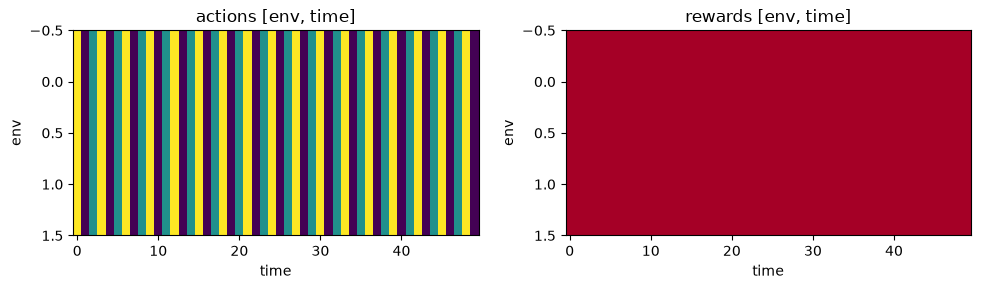

In [23]:
actions = jnp.stack([jnp.asarray([item.action_id for item in decision.actions]) for decision in rollout.decisions])
rewards = jnp.stack([decision.transition.reward for decision in rollout.decisions])
figure, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].imshow(actions.T, aspect='auto', interpolation='nearest')
axes[0].set(title='actions [env, time]', xlabel='time', ylabel='env')
axes[1].imshow(rewards.T, aspect='auto', interpolation='nearest', cmap='RdYlGn')
axes[1].set(title='rewards [env, time]', xlabel='time', ylabel='env')
figure.tight_layout()
plt.show()


## Что остаётся до production PPO/RLCluster update

1. `RLCluster` создаёт production trainable actor, frozen reference и, для PPO-profile, trainable critic на role meshes.
2. Сейчас notebook использует компактный Flax token actor-critic bridge: full-token PPO включает все generated tokens через `token_mask`, actor пересчитывает `new_logprobs`, critic выдаёт values, Optax реально меняет параметры.
3. Safe policy-only режим остаётся доступен как `token_ppo_update()` и учится только по `policy_mask`; этот notebook намеренно показывает полный режим `full_token_ppo_update()`.
4. Следующий production шаг — заменить этот bridge на Qwen/RLCluster actor/value path и проверить parity на accelerator.
5. Checkpoint должен сохранять actor, critic, optimizer, policy version и evidence manifest.
